# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Tahta Karisma Tiwi Shine Prameswari
- **Email:** 23082010130@student.upnjatim.ac.id
- **ID Dicoding:** tahtaprameswari

## Menentukan Pertanyaan Bisnis

- Bagaimana pola penggunaan sepeda berubah berdasarkan jam, hari kerja/libur, dan hari dalam seminggu?
- Bagaimana musim dan kondisi cuaca memengaruhi jumlah penyewaan sepeda?
- Bagaimana perubahan jumlah penyewaan sepeda dari 2011 ke 2012, dan kapan periode permintaan tertinggi terjadi?
- Bagaimana perbedaan perilaku pengguna casual dan registered berdasarkan waktu serta kondisi tertentu?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data
Pada tahap ini, data dikumpulkan dari dua file utama dalam Bike Sharing Dataset, yaitu `hour.csv` dan `day.csv`.  
Dataset `hour.csv` digunakan untuk menganalisis pola penyewaan sepeda pada level jam, sedangkan `day.csv` digunakan untuk melihat pola penyewaan pada level harian.

Tahap ini bertujuan untuk:
- memuat data ke dalam DataFrame,
- memahami struktur awal data,
- melihat jumlah baris dan kolom,
- serta meninjau sampel data sebelum masuk ke tahap penilaian kualitas data.


In [ ]:
# Memuat dataset
hour_df = pd.read_csv("data/hour.csv")
day_df = pd.read_csv("data/day.csv")

# Menampilkan 5 data teratas
display(hour_df.head())
display(day_df.head())

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
# Menampilkan ukuran dataset
print("Ukuran hour_df:", hour_df.shape)
print("Ukuran day_df:", day_df.shape)

Ukuran hour_df: (17379, 17)
Ukuran day_df: (731, 16)


**Insight:**
- Proses pengumpulan data menunjukkan bahwa Bike Sharing Dataset tersedia dalam dua tingkat agregasi, yaitu data per jam (`hour.csv`) dan data per hari (`day.csv`).
- Dataset `hour.csv` berisi 17.379 observasi dan 17 variabel, sedangkan `day.csv` berisi 731 observasi dan 16 variabel, sehingga keduanya dapat saling melengkapi dalam analisis pola permintaan sepeda.
- Keberadaan kolom `hr` pada `hour.csv` memberikan nilai tambah untuk menganalisis pola penggunaan sepeda secara lebih rinci berdasarkan waktu, sementara `day.csv` mendukung analisis tren yang lebih agregatif.

### Assessing Data

Pada tahap ini dilakukan penilaian kualitas data untuk mengidentifikasi potensi masalah yang dapat memengaruhi hasil analisis.  
Pemeriksaan dilakukan terhadap:
- tipe data setiap kolom,
- missing values,
- duplikasi data,
- statistik deskriptif,
- serta kolom kategorikal yang masih direpresentasikan dalam bentuk kode numerik.

Tahap ini penting agar proses cleaning data dapat dilakukan secara tepat sebelum masuk ke analisis lebih lanjut.

In [ ]:
# Informasi umum dataset
hour_df.info()
print("\n" + "="*50 + "\n")
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


<class 'pandas.core.frame.DataFrame'>
RangeInde

In [ ]:
# Mengecek missing values
print("Missing values pada hour_df:")
print(hour_df.isna().sum())

print("\n" + "="*50 + "\n")

print("Missing values pada day_df:")
print(day_df.isna().sum())

Missing values pada hour_df:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


Missing values pada day_df:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [ ]:
# Mengecek duplikasi data
print("Jumlah duplikasi pada hour_df:", hour_df.duplicated().sum())
print("Jumlah duplikasi pada day_df:", day_df.duplicated().sum())

Jumlah duplikasi pada hour_df: 0
Jumlah duplikasi pada day_df: 0


In [ ]:
# Statistik deskriptif
display(hour_df.describe())
display(day_df.describe())

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [ ]:
# Mengecek nilai unik pada beberapa kolom kategorikal
categorical_cols_hour = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
categorical_cols_day = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']

print("Nilai unik pada hour_df:")
for col in categorical_cols_hour:
    print(f"{col}: {sorted(hour_df[col].unique().tolist())}")

print("\n" + "="*50 + "\n")

print("Nilai unik pada day_df:")
for col in categorical_cols_day:
    print(f"{col}: {sorted(day_df[col].unique().tolist())}")

Nilai unik pada hour_df:
season: [1, 2, 3, 4]
yr: [0, 1]
mnth: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
hr: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
holiday: [0, 1]
weekday: [0, 1, 2, 3, 4, 5, 6]
workingday: [0, 1]
weathersit: [1, 2, 3, 4]


Nilai unik pada day_df:
season: [1, 2, 3, 4]
yr: [0, 1]
mnth: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
holiday: [0, 1]
weekday: [0, 1, 2, 3, 4, 5, 6]
workingday: [0, 1]
weathersit: [1, 2, 3]


**Insight:**
- Dataset bersih dari missing values dan tidak ada duplikasi, sehingga kualitas awal data cukup baik untuk analisis lebih lanjut.
- Kolom `dteday` masih bertipe object, sehingga perlu dikonversi menjadi datetime agar analisis berbasis waktu lebih akurat.
- Kolom kategorikal seperti `season`, `yr`, `mnth`, `holiday`, `weekday`, `workingday`, dan `weathersit` masih dalam bentuk kode numerik, perlu dimapping ke label deskriptif untuk mempermudah interpretasi.
- `day_df` hanya memiliki `weathersit` 1–3, sementara `hour_df` ada kategori 4; menunjukkan kondisi cuaca ekstrem jarang terjadi pada level harian.
- Distribusi `cnt` menunjukkan nilai mean > median pada level jam, mengindikasikan permintaan tidak simetris dengan beberapa jam puncak yang tinggi.
- Jumlah `registered` pengguna jauh lebih tinggi daripada `casual` baik di level jam maupun harian, hal ini bisa menjadi fokus segmentasi analisis pengguna.

### Cleaning Data

Pada tahap ini, kita akan membersihkan dan menyiapkan data agar siap untuk analisis.  
Langkah-langkah yang dilakukan:
1. Mengubah kolom `dteday` menjadi tipe data datetime.
2. Memetakan kolom numerik kategori ke label deskriptif:
   - `season`: 1–4 → Spring, Summer, Fall, Winter
   - `weathersit`: 1–4 → Clear, Mist, Light Rain/Snow, Heavy Rain/Snow
   - `yr`: 0–1 → 2011, 2012
   - `mnth`: 1–12 → Januari–Desember
   - `weekday`: 0–6 → Senin–Minggu
3. Membuat kolom turunan tambahan untuk `hour_df`:
   - `time_segment`: membagi 24 jam menjadi segmen pagi, siang, sore, malam
4. Mengecek hasil cleaning dengan menampilkan 5 baris pertama dataset.

In [ ]:
# Konversi dteday menjadi datetime
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

# Cek tipe data
hour_df.dtypes, day_df.dtypes

(instant                int64
 dteday        datetime64[ns]
 season                 int64
 yr                     int64
 mnth                   int64
 hr                     int64
 holiday                int64
 weekday                int64
 workingday             int64
 weathersit             int64
 temp                 float64
 atemp                float64
 hum                  float64
 windspeed            float64
 casual                 int64
 registered             int64
 cnt                    int64
 dtype: object,
 instant                int64
 dteday        datetime64[ns]
 season                 int64
 yr                     int64
 mnth                   int64
 holiday                int64
 weekday                int64
 workingday             int64
 weathersit             int64
 temp                 float64
 atemp                float64
 hum                  float64
 windspeed            float64
 casual                 int64
 registered             int64
 cnt                    

In [ ]:
# Mapping season
season_map = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
hour_df['season_label'] = hour_df['season'].map(season_map)
day_df['season_label'] = day_df['season'].map(season_map)

# Mapping weather
weather_map = {1: "Clear", 2: "Mist", 3: "Light Rain/Snow", 4: "Heavy Rain/Snow"}
hour_df['weather_label'] = hour_df['weathersit'].map(weather_map)
day_df['weather_label'] = day_df['weathersit'].map(lambda x: weather_map.get(x, "Unknown"))

# Mapping year
year_map = {0: 2011, 1: 2012}
hour_df['year_label'] = hour_df['yr'].map(year_map)
day_df['year_label'] = day_df['yr'].map(year_map)

# Mapping month
month_map = {1: "January",2: "February",3: "March",4: "April",5: "May",6: "June",
             7: "July",8: "August",9: "September",10: "October",11: "November",12: "December"}
hour_df['month_name'] = hour_df['mnth'].map(month_map)
day_df['month_name'] = day_df['mnth'].map(month_map)

# Mapping weekday
weekday_map = {0: "Monday",1: "Tuesday",2: "Wednesday",3: "Thursday",4: "Friday",
               5: "Saturday",6: "Sunday"}
hour_df['weekday_name'] = hour_df['weekday'].map(weekday_map)
day_df['weekday_name'] = day_df['weekday'].map(weekday_map)

In [ ]:
# Membagi 24 jam menjadi 4 segmen
def get_time_segment(hr):
    if 5 <= hr < 12:
        return "Morning"
    elif 12 <= hr < 17:
        return "Afternoon"
    elif 17 <= hr < 21:
        return "Evening"
    else:
        return "Night"

hour_df['time_segment'] = hour_df['hr'].apply(get_time_segment)

# Cek distribusi segmen
hour_df['time_segment'].value_counts()

,count
time_segment,
Night,5743
Morning,5077
Afternoon,3645
Evening,2914


In [ ]:
# Menampilkan 5 baris pertama hour_df dan day_df setelah cleaning
display(hour_df.head())
display(day_df.head())

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,windspeed,casual,registered,cnt,season_label,weather_label,year_label,month_name,weekday_name,time_segment
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,0.0,3,13,16,Spring,Clear,2011,January,Sunday,Night
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,0.0,8,32,40,Spring,Clear,2011,January,Sunday,Night
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,0.0,5,27,32,Spring,Clear,2011,January,Sunday,Night
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,0.0,3,10,13,Spring,Clear,2011,January,Sunday,Night
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0.0,0,1,1,Spring,Clear,2011,January,Sunday,Night


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,...,hum,windspeed,casual,registered,cnt,season_label,weather_label,year_label,month_name,weekday_name
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,...,0.805833,0.160446,331,654,985,Spring,Mist,2011,January,Sunday
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,...,0.696087,0.248539,131,670,801,Spring,Mist,2011,January,Monday
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,...,0.437273,0.248309,120,1229,1349,Spring,Clear,2011,January,Tuesday
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,...,0.590435,0.160296,108,1454,1562,Spring,Clear,2011,January,Wednesday
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,...,0.436957,0.186900,82,1518,1600,Spring,Clear,2011,January,Thursday


**Insight:**
- Kolom `dteday` telah berhasil dikonversi menjadi tipe datetime, memungkinkan analisis tren harian maupun jam secara akurat.
- Semua kolom kategori seperti `season`, `weathersit`, `yr`, `mnth`, dan `weekday` telah dimapping menjadi label deskriptif (`season_label`, `weather_label`, `year_label`, `month_name`, `weekday_name`), sehingga interpretasi data lebih mudah dan intuitif.
- Untuk `hour_df`, kolom tambahan `time_segment` berhasil dibuat, membagi 24 jam menjadi empat segmen (Morning, Afternoon, Evening, Night) yang mempermudah analisis pola penggunaan sepeda berdasarkan waktu.
- Data telah siap untuk tahap EDA, karena tidak ada missing values, tidak ada duplikasi, dan representasi kategorikal kini jelas.
- Distribusi `time_segment` menunjukkan penggunaan sepeda paling tinggi pada Afternoon dan Evening, sementara Night memiliki penggunaan paling rendah, memberikan insight awal terkait pola permintaan.

### Exploratory Data Analysis (EDA)

Tujuan dari EDA adalah memahami data lebih dalam, menemukan pola, hubungan antar variabel, dan insight awal yang dapat menjawab pertanyaan bisnis.  
Pada tahap ini, kita akan:
1. Melihat distribusi jumlah penyewaan sepeda (`cnt`) harian dan per jam.
2. Mengidentifikasi tren musiman, tren per tahun, dan tren berdasarkan hari kerja/libur.
3. Mengeksplorasi korelasi antara variabel numerik seperti `temp`, `atemp`, `hum`, `windspeed` dengan jumlah penyewaan (`cnt`).
4. Mengamati perbedaan penggunaan sepeda antara pengguna casual dan registered.

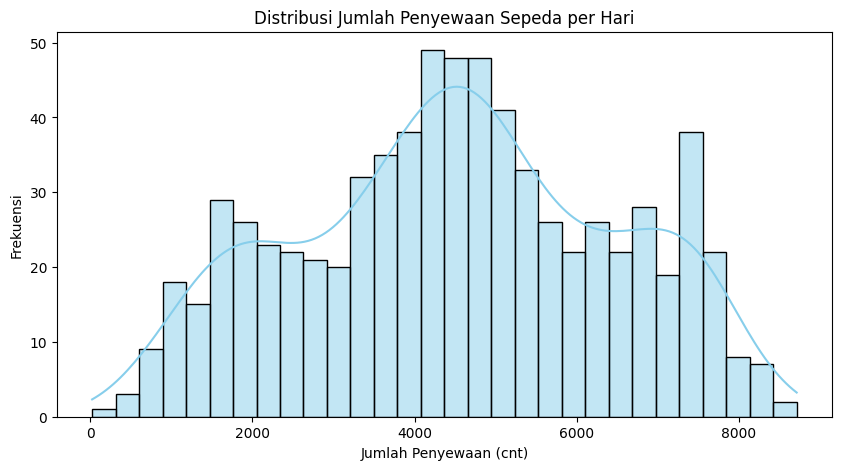

In [ ]:
# Import library visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram jumlah penyewaan per hari
plt.figure(figsize=(10,5))
sns.histplot(day_df['cnt'], bins=30, kde=True, color='skyblue')
plt.title('Distribusi Jumlah Penyewaan Sepeda per Hari')
plt.xlabel('Jumlah Penyewaan (cnt)')
plt.ylabel('Frekuensi')
plt.show()

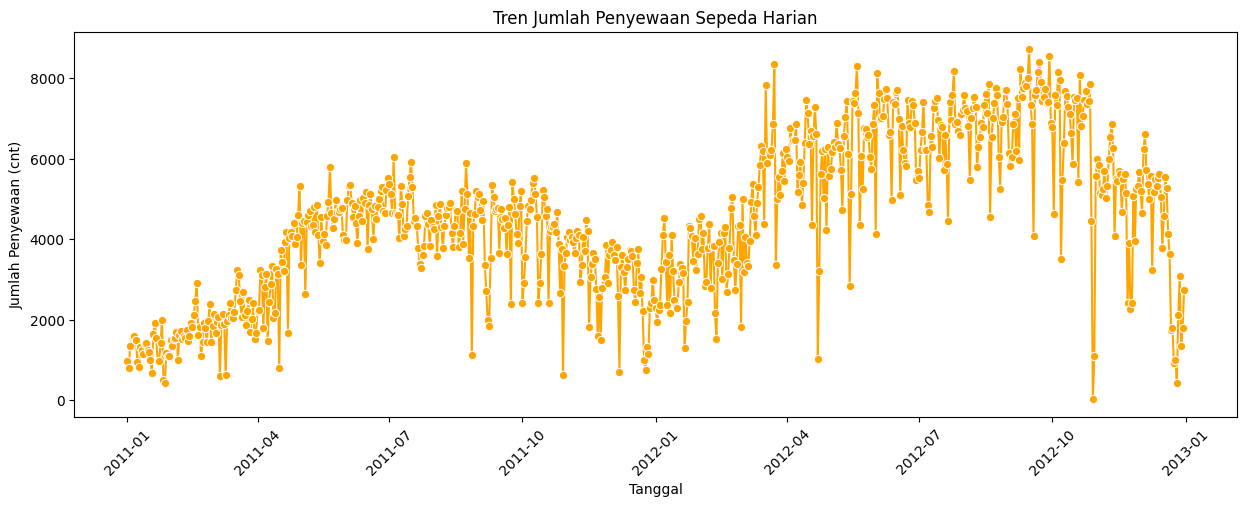

In [ ]:
# Tren jumlah penyewaan sepeda harian
plt.figure(figsize=(15,5))
sns.lineplot(x='dteday', y='cnt', data=day_df, marker='o', color='orange')
plt.title('Tren Jumlah Penyewaan Sepeda Harian')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Penyewaan (cnt)')
plt.xticks(rotation=45)
plt.show()

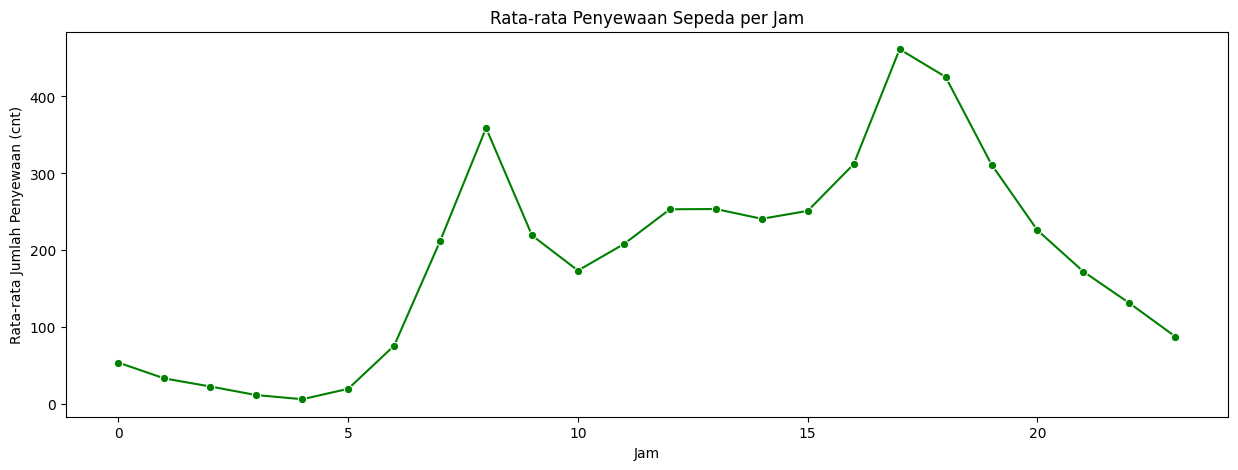

In [ ]:
# Tren penyewaan sepeda per jam
plt.figure(figsize=(15,5))
sns.lineplot(x='hr', y='cnt', data=hour_df.groupby('hr')['cnt'].mean().reset_index(), marker='o', color='green')
plt.title('Rata-rata Penyewaan Sepeda per Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Jumlah Penyewaan (cnt)')
plt.show()

/tmp/ipykernel_155/3955952227.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='season_label', y='cnt', data=day_df, palette='Pastel1')


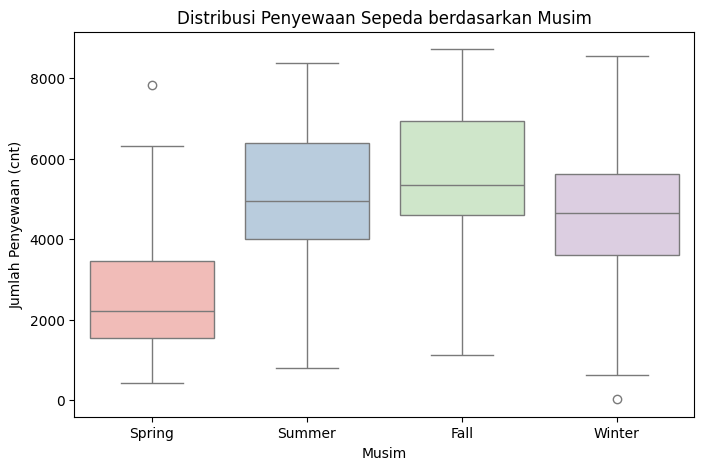

/tmp/ipykernel_155/3955952227.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weather_label', y='cnt', data=day_df, palette='Pastel2')


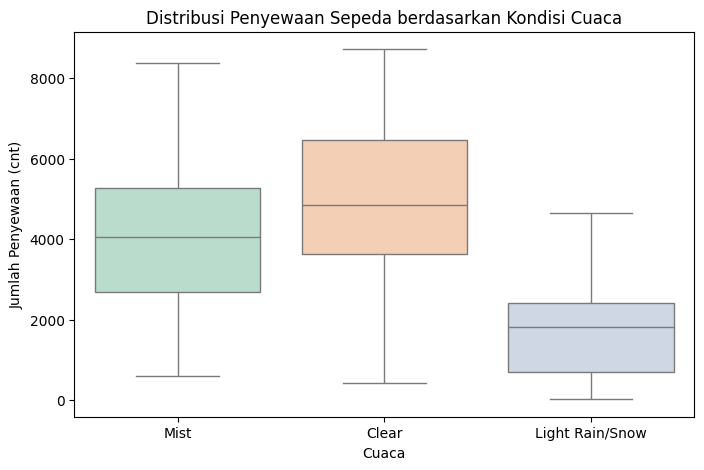

In [ ]:
# Boxplot cnt berdasarkan season
plt.figure(figsize=(8,5))
sns.boxplot(x='season_label', y='cnt', data=day_df, palette='Pastel1')
plt.title('Distribusi Penyewaan Sepeda berdasarkan Musim')
plt.xlabel('Musim')
plt.ylabel('Jumlah Penyewaan (cnt)')
plt.show()

# Boxplot cnt berdasarkan weather
plt.figure(figsize=(8,5))
sns.boxplot(x='weather_label', y='cnt', data=day_df, palette='Pastel2')
plt.title('Distribusi Penyewaan Sepeda berdasarkan Kondisi Cuaca')
plt.xlabel('Cuaca')
plt.ylabel('Jumlah Penyewaan (cnt)')
plt.show()

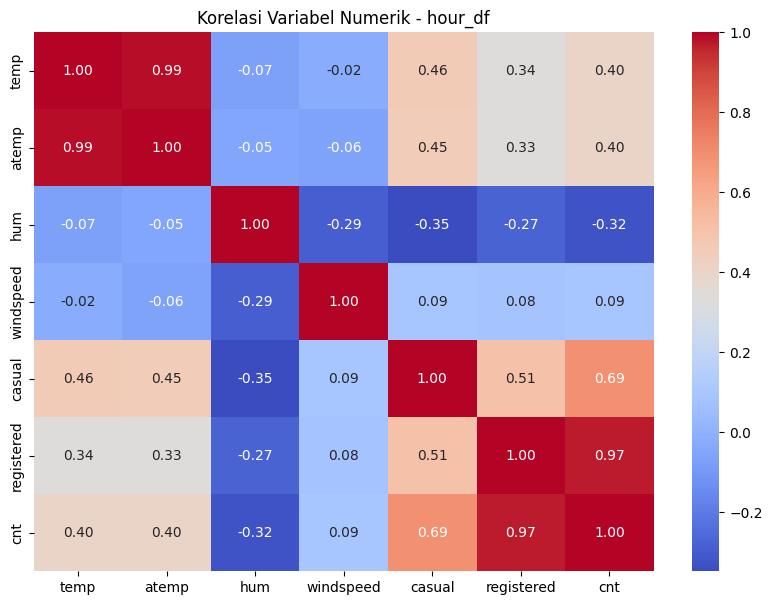

In [ ]:
# Korelasi variabel numerik
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
corr = hour_df[numeric_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi Variabel Numerik - hour_df')
plt.show()

### Explore ...

**Insight:**
- Permintaan penyewaan sepeda tidak terdistribusi merata, melainkan berfluktuasi cukup besar antar hari.
- Terdapat kecenderungan peningkatan jumlah penyewaan dari 2011 ke 2012, yang menunjukkan pertumbuhan penggunaan layanan bike sharing.
- Pola rata-rata penyewaan per jam memperlihatkan dua periode sibuk utama, yaitu pagi dan sore hari, yang mengarah pada indikasi penggunaan untuk perjalanan rutin atau komuter.
- Musim berpengaruh terhadap jumlah penyewaan, dengan musim tertentu menghasilkan tingkat permintaan yang lebih tinggi dibanding musim lainnya.
- Kondisi cuaca yang lebih baik berkorelasi dengan penyewaan yang lebih tinggi, sedangkan cuaca buruk cenderung menurunkan jumlah penyewaan.
- Temuan awal ini menunjukkan bahwa waktu, musim, dan cuaca merupakan faktor utama yang membentuk pola permintaan bike sharing.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pola penggunaan sepeda berdasarkan jam, hari kerja/libur, dan hari dalam seminggu

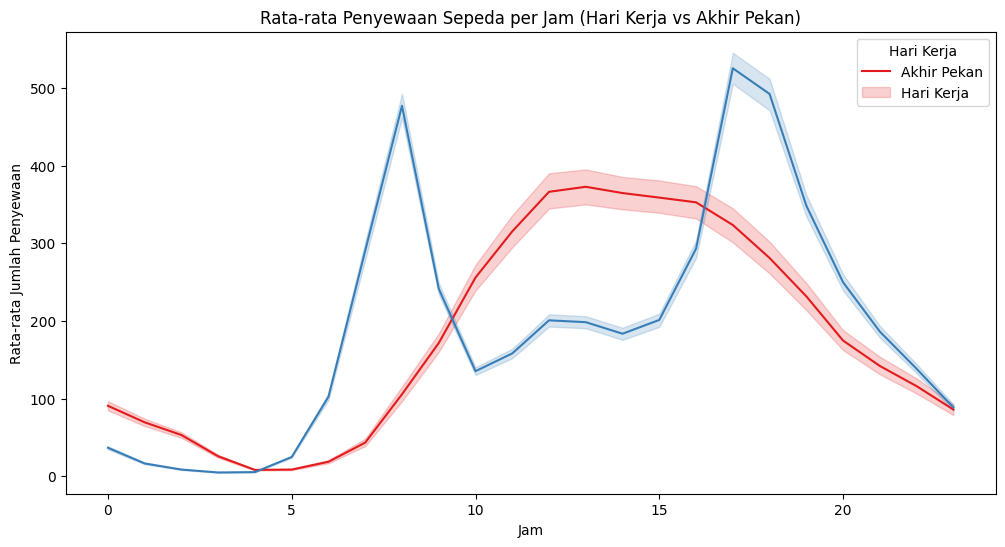

In [ ]:
# Line chart jumlah penyewaan sepeda rata-rata per jam, dipisahkan hari kerja vs libur
plt.figure(figsize=(12,6))
sns.lineplot(x='hr', y='cnt', hue='workingday', data=hour_df, palette='Set1', estimator='mean')
plt.title('Rata-rata Penyewaan Sepeda per Jam (Hari Kerja vs Akhir Pekan)')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.legend(title='Hari Kerja', labels=['Akhir Pekan', 'Hari Kerja'])
plt.show()

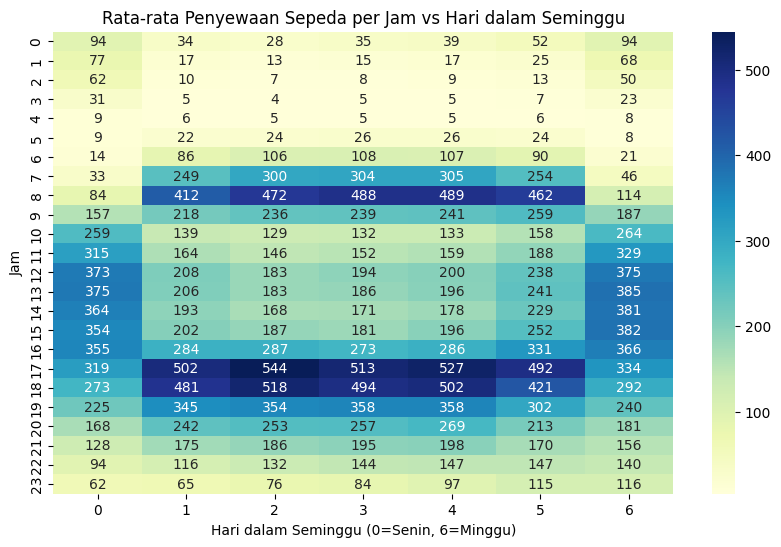

In [ ]:
# Heatmap penyewaan sepeda berdasarkan jam dan weekday
pivot_hour_weekday = hour_df.pivot_table(values='cnt', index='hr', columns='weekday', aggfunc='mean')
plt.figure(figsize=(10,6))
sns.heatmap(pivot_hour_weekday, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title('Rata-rata Penyewaan Sepeda per Jam vs Hari dalam Seminggu')
plt.xlabel('Hari dalam Seminggu (0=Senin, 6=Minggu)')
plt.ylabel('Jam')
plt.show()

**Insight:**
- Hari kerja memiliki dua jam sibuk utama, yaitu pagi dan sore, yang mencerminkan pola perjalanan rutin atau komuter.
- Akhir pekan tidak menunjukkan lonjakan tajam pada pagi hari, tetapi memiliki permintaan yang lebih stabil dari siang hingga sore.
- Perbedaan pola ini menunjukkan bahwa jenis hari sangat memengaruhi perilaku penggunaan sepeda.

### Pertanyaan 2:Musim dan kondisi cuaca terhadap jumlah penyewaan

/tmp/ipykernel_155/2082097167.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='season_label', y='cnt', data=season_avg, palette='Set2')


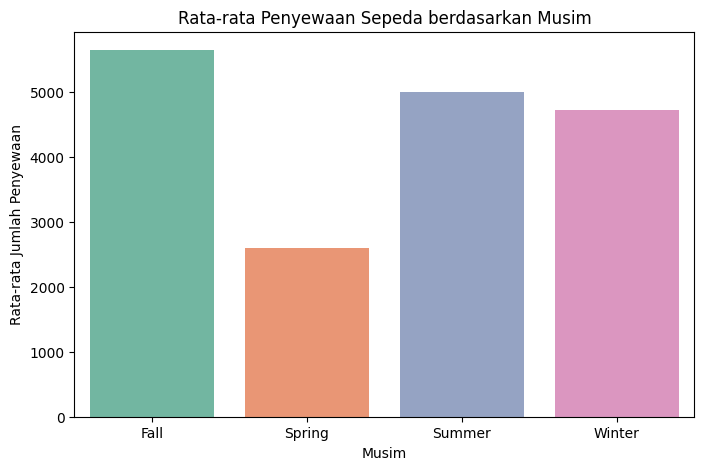

In [24]:
# Rata-rata jumlah penyewaan berdasarkan musim
season_avg = day_df.groupby('season_label')['cnt'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='season_label', y='cnt', data=season_avg, palette='Set2')
plt.title('Rata-rata Penyewaan Sepeda berdasarkan Musim')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.show()

/tmp/ipykernel_155/569373667.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weather_label', y='cnt', data=weather_avg, palette='Set3')


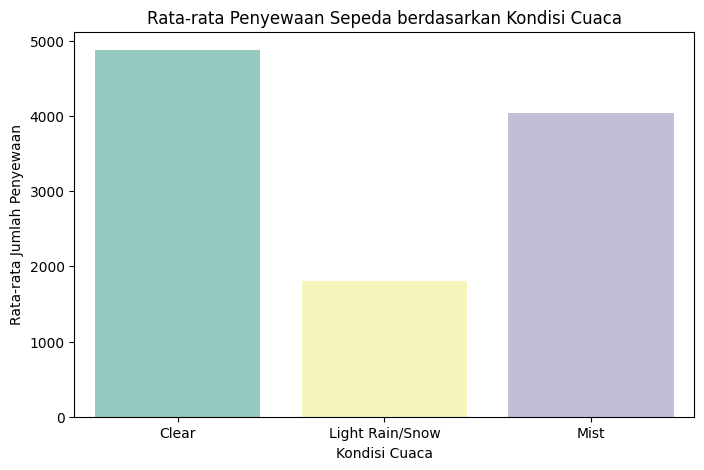

In [25]:
# Rata-rata jumlah penyewaan berdasarkan kondisi cuaca
weather_avg = day_df.groupby('weather_label')['cnt'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='weather_label', y='cnt', data=weather_avg, palette='Set3')
plt.title('Rata-rata Penyewaan Sepeda berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.show()

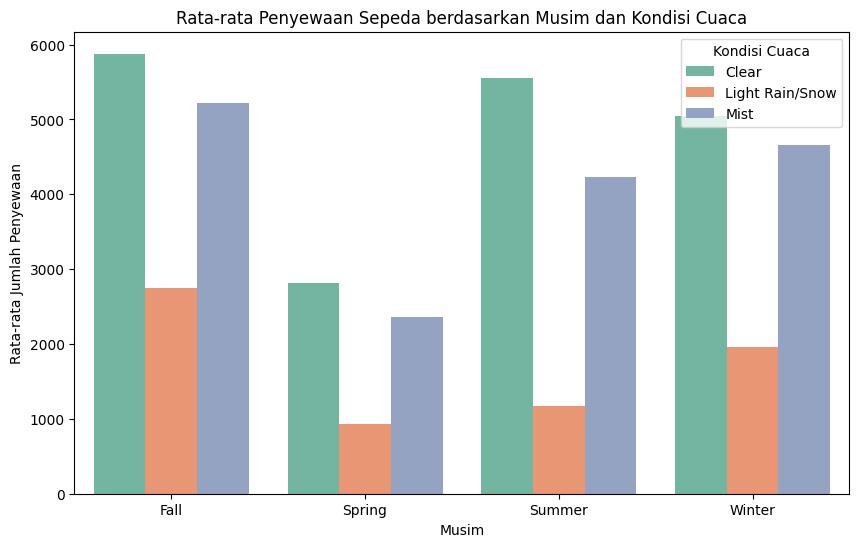

In [26]:
# Rata-rata jumlah penyewaan berdasarkan kombinasi musim dan kondisi cuaca
season_weather_avg = day_df.groupby(['season_label', 'weather_label'])['cnt'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='season_label', y='cnt', hue='weather_label', data=season_weather_avg, palette='Set2')
plt.title('Rata-rata Penyewaan Sepeda berdasarkan Musim dan Kondisi Cuaca')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.legend(title='Kondisi Cuaca')
plt.show()

**Insight:**
- Musim panas dan musim gugur menjadi periode dengan permintaan penyewaan yang paling tinggi.
- Cuaca cerah mendorong jumlah penyewaan yang lebih besar di setiap musim.
- Hujan ringan atau salju ringan menurunkan permintaan secara signifikan, sehingga faktor cuaca perlu diperhatikan dalam perencanaan operasional.

### Pertanyaan 3 : Perubahan jumlah penyewaan 2011 vs 2012 dan periode puncak

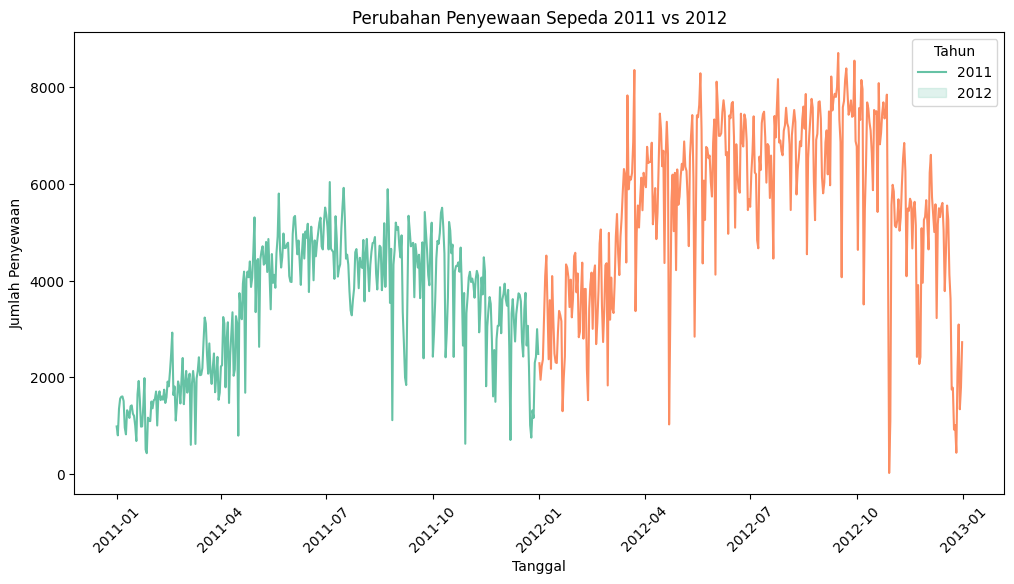

In [ ]:
# Line chart total penyewaan harian per tahun
daily_counts = day_df.groupby(['dteday','yr'])['cnt'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(x='dteday', y='cnt', hue='yr', data=daily_counts, palette='Set2')
plt.title('Perubahan Penyewaan Sepeda 2011 vs 2012')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Penyewaan')
plt.legend(title='Tahun', labels=['2011','2012'])
plt.xticks(rotation=45)
plt.show()

**Insight:**
- Tahun 2012 mencatat performa penyewaan yang lebih tinggi dibanding 2011 hampir di seluruh periode.
- Permintaan mencapai puncaknya pada pertengahan hingga akhir tahun, terutama saat memasuki musim dengan kondisi yang lebih mendukung penggunaan sepeda.
- Pola ini menunjukkan adanya pertumbuhan tahunan sekaligus seasonality yang kuat pada layanan bike sharing.

### Pertanyaan 4 : Perbedaan perilaku casual danregistered

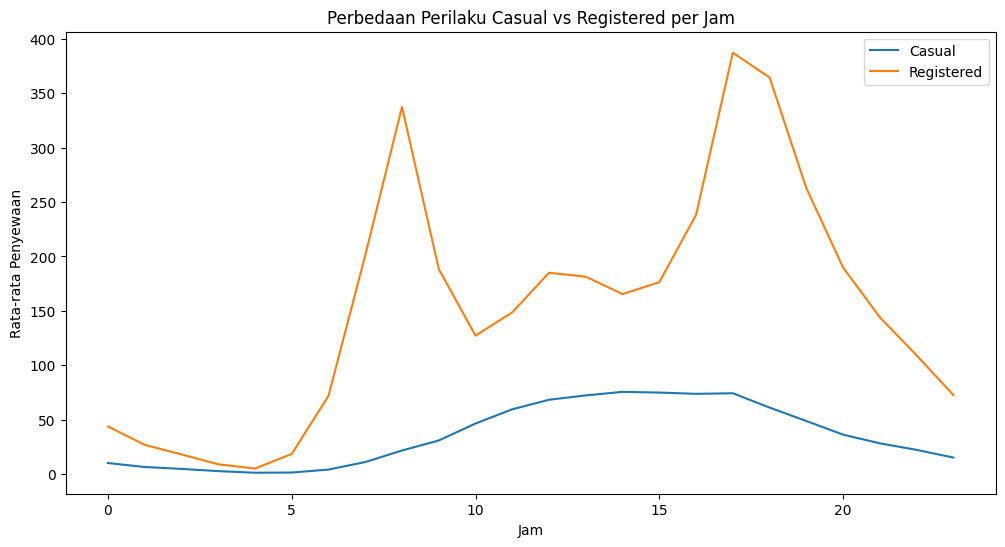

In [ ]:
# Line chart jumlah penyewaan casual vs registered per jam rata-rata
hourly_user = hour_df.groupby('hr')[['casual','registered']].mean().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(x='hr', y='casual', data=hourly_user, label='Casual')
sns.lineplot(x='hr', y='registered', data=hourly_user, label='Registered')
plt.title('Perbedaan Perilaku Casual vs Registered per Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.legend()
plt.show()

**Insight:**
- Registered users merupakan kontributor utama penyewaan sepeda dan menunjukkan pola komuter yang sangat kuat.
- Casual users memiliki aktivitas yang lebih rendah dan lebih terkonsentrasi pada jam santai, terutama setelah pagi hingga sore.
- Segmentasi ini menunjukkan bahwa strategi layanan dan promosi dapat dibedakan antara pengguna rutin dan pengguna non-rutin.

**Insight Visualisasi **
- Pola penggunaan sepeda berbeda jelas antara hari kerja dan akhir pekan, dengan lonjakan komuter yang kuat pada hari kerja.
- Musim dan kondisi cuaca memengaruhi tingkat permintaan, di mana cuaca cerah dan musim tertentu mendorong penyewaan yang lebih tinggi.
- Tahun 2012 menunjukkan jumlah penyewaan yang lebih tinggi dibanding 2011, menandakan pertumbuhan penggunaan layanan bike sharing.
- Pengguna registered mendominasi penyewaan dan menunjukkan pola rutin harian, sedangkan pengguna casual cenderung lebih aktif pada jam yang lebih santai.

## Analisis Lanjutan (Opsional)

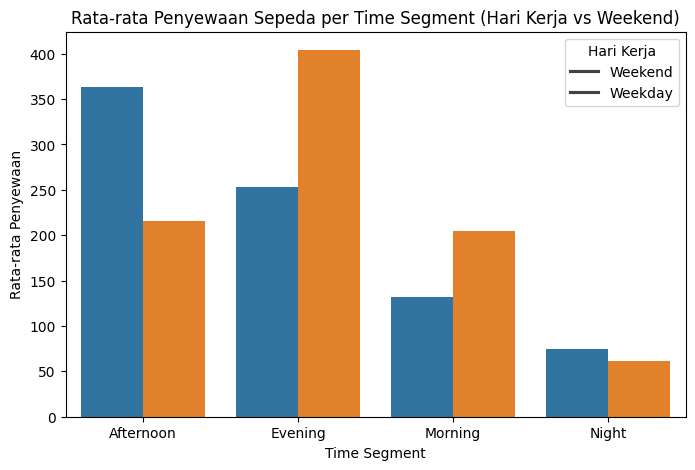

In [30]:
# Pivot table untuk visualisasi
cluster_pivot = hour_df.groupby(['time_segment', 'workingday'])['cnt'].mean().reset_index()

# Visualisasi bar chart
plt.figure(figsize=(8,5))
sns.barplot(x='time_segment', y='cnt', hue='workingday', data=cluster_pivot)
plt.title('Rata-rata Penyewaan Sepeda per Time Segment (Hari Kerja vs Weekend)')
plt.xlabel('Time Segment')
plt.ylabel('Rata-rata Penyewaan')
plt.legend(title='Hari Kerja', labels=['Weekend', 'Weekday'])
plt.show()

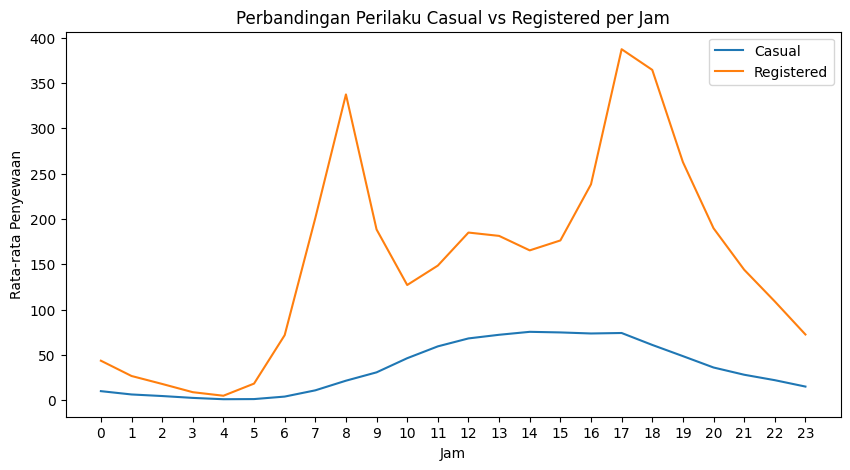

In [31]:
# Pivot table rata-rata penyewaan per jam
rental_behavior = hour_df.groupby('hr')[['casual', 'registered']].mean().reset_index()

# Line chart
plt.figure(figsize=(10,5))
sns.lineplot(x='hr', y='casual', data=rental_behavior, label='Casual')
sns.lineplot(x='hr', y='registered', data=rental_behavior, label='Registered')
plt.title('Perbandingan Perilaku Casual vs Registered per Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(0,24))
plt.legend()
plt.show()

**Insight tambahan**
- Penggunaan sepeda tertinggi pada weekday pagi dan sore untuk registered users, menunjukkan aktivitas commuting ke tempat kerja atau sekolah.
- Weekend peak terjadi pada afternoon, didominasi oleh casual users, menandakan penggunaan untuk rekreasi atau aktivitas santai.

- Registered users secara keseluruhan menyumbang volume penyewaan yang jauh lebih tinggi dibanding casual users, dengan pola jam yang jelas terkait jam kerja.
- Night segment rendah untuk semua pengguna, menandakan sedikit aktivitas penyewaan di malam hari.
- Pola ini dapat menjadi dasar strategi alokasi sepeda, distribusi stasiun, dan maintenance agar sesuai dengan kebutuhan pengguna berdasarkan hari, jam, dan tipe pengguna.

## Conclusion

## Conclusion

1. **Pola penggunaan sepeda berdasarkan waktu dan hari**
   - Pada hari kerja, permintaan sepeda memuncak pada jam pagi dan sore, menunjukkan pola perjalanan komuter.
   - Pada akhir pekan, permintaan tertinggi terjadi pada siang hingga sore, menandakan penggunaan rekreasi.

2. **Pengaruh musim dan kondisi cuaca**
   - Musim Summer dan Fall menunjukkan penyewaan tertinggi.
   - Cuaca Clear mendorong permintaan lebih tinggi dibandingkan Mist atau Light Rain/Snow, sehingga faktor lingkungan signifikan memengaruhi perilaku pengguna.

3. **Perubahan jumlah penyewaan antara 2011 dan 2012**
   - Terdapat peningkatan jumlah penyewaan dari 2011 ke 2012.
   - Puncak permintaan terjadi pada pertengahan hingga akhir tahun, menunjukkan adanya tren musiman yang konsisten.

4. **Perbedaan perilaku pengguna casual dan registered**
   - Pengguna registered mendominasi dan mengikuti pola komuter, dengan puncak pada jam pagi dan sore.
   - Pengguna casual cenderung meningkat pada siang hingga sore, menandakan penggunaan non-rutin atau rekreasi.

5. **Analisis lanjutan dan insight operasional**
   - Permintaan dipengaruhi oleh kombinasi faktor: jam, jenis hari, musim, cuaca, dan tipe pengguna.
   - Segmentasi waktu menunjukkan weekday evening sebagai periode terpadat, sedangkan weekend afternoon menjadi dominan untuk penggunaan santai.
   - Temuan ini relevan untuk keputusan operasional: penempatan sepeda strategis, jadwal redistribusi, dan prioritas maintenance pada periode demand tertinggi.

**Kesimpulan umum:** Analisis ini menegaskan bahwa permintaan layanan bike sharing sangat dipengaruhi oleh faktor temporal, musiman, cuaca, dan tipe pengguna. Strategi operasional dan penentuan kapasitas sebaiknya mempertimbangkan kombinasi faktor-faktor ini untuk mengoptimalkan layanan.

In [33]:
main_data = hour_df[[
    'dteday',
    'hr',
    'season_label',
    'weather_label',
    'year_label',
    'month_name',
    'weekday_name',
    'workingday',
    'time_segment',
    'temp',
    'atemp',
    'hum',
    'windspeed',
    'casual',
    'registered',
    'cnt'
]].copy()

In [34]:
main_data.to_csv("main_data.csv", index=False)